In [4]:
import pandas as pd

target_groups = ['m3049','mover50', 'fover50', 'm1229', 'f3049', 'f1229']
channel_list = [0,3501,3403,3404,3303,3302,3401,3402,3306,3301,3400,3305,3304,3300,3103,3101,3100,3102]

df = pd.read_csv("concurrent_weighted_viewers.csv")
df["ts"] = pd.to_datetime(df["ts"])

In [5]:
df.dtypes

tv_date                    str
channel_id               int64
target_group               str
ts              datetime64[us]
num_sessions             int64
weighted_sum           float64
dtype: object

In [6]:
df = df[df["tv_date"] == "2025-09-07"]
group = "m1229"

group_data = df[df['target_group'] == group]
print(group_data.shape)
group_data.head()

(14595, 6)


,tv_date,channel_id,target_group,ts,num_sessions,weighted_sum
55631,2025-09-07,0,m1229,2025-09-07 01:00:00,6,68.736364
55632,2025-09-07,0,m1229,2025-09-07 01:01:54,1,33.137522
55633,2025-09-07,0,m1229,2025-09-07 01:01:57,1,28.403590
55634,2025-09-07,0,m1229,2025-09-07 01:02:00,1,33.137522
55635,2025-09-07,0,m1229,2025-09-07 01:02:01,1,28.403590


In [13]:
import matplotlib.pyplot as plt

def plot_target_group(df, tv_date, group):
    # Filter and sort once
    filtered_df = df[(df["tv_date"] == tv_date) & (df["target_group"]==group)].sort_values('ts')

    # Create line plot with ts as x-axis
    plt.figure(figsize=(14, 7))

    for channel_id, data in filtered_df.groupby('channel_id'):
        plt.plot(data['ts'], data['weighted_sum'], label=f'Channel {channel_id}')

    plt.xlabel('Timestamp')
    plt.ylabel('Weighted Sum')
    plt.title('Weighted Viewers by Channel ID Over Time')
    plt.xticks(rotation=45)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    plt.tight_layout()
    plt.show()

    print(f"Total records: {len(filtered_df)}, Channels: {filtered_df['channel_id'].nunique()}")

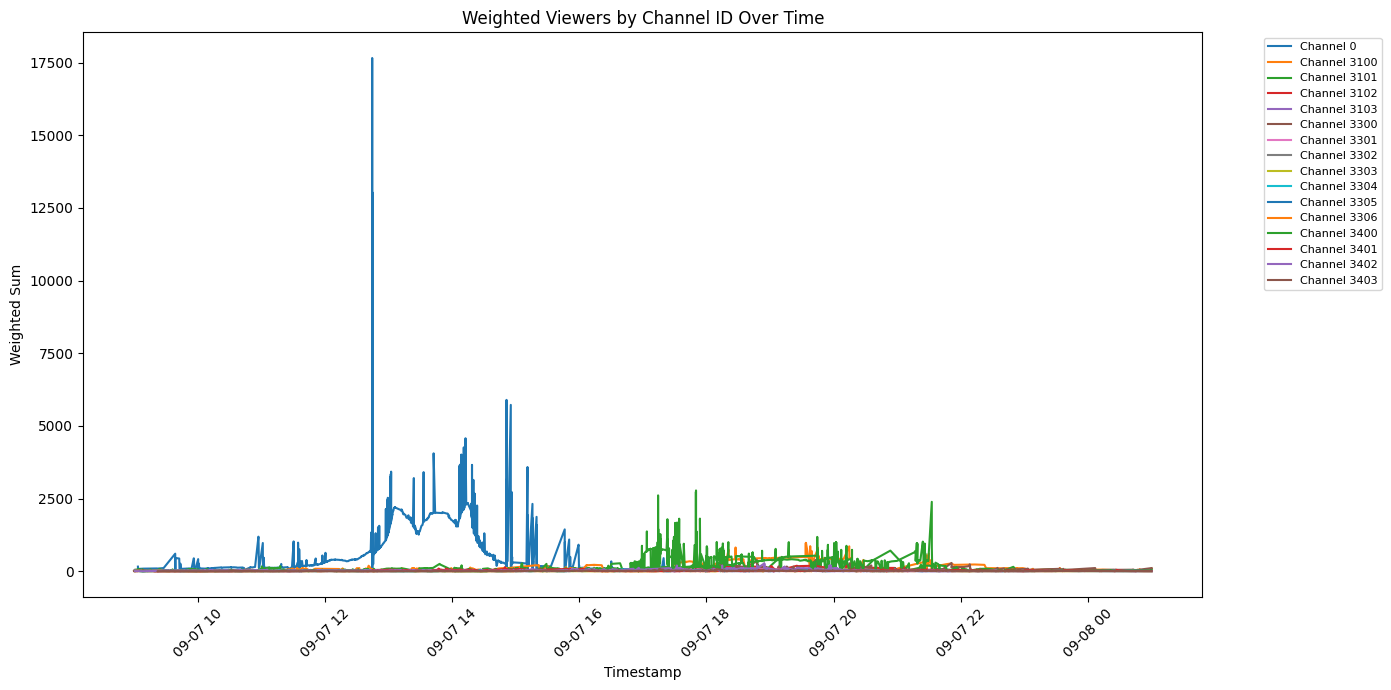

Total records: 11825, Channels: 16


In [15]:
plot_target_group(df[df["ts"] >pd.to_datetime("2025-09-07 09:00") ], tv_date="2025-09-07",group="m1229")

In [8]:
filtered_df.sort_values("weighted_sum", ascending=False)[0:20]

,tv_date,channel_id,target_group,ts,num_sessions,weighted_sum
56217,2025-09-07,0,m1229,2025-09-07 12:44:43,60,17659.506508
56220,2025-09-07,0,m1229,2025-09-07 12:45:01,54,13029.554489
56734,2025-09-07,0,m1229,2025-09-07 14:51:26,33,5895.960565
56740,2025-09-07,0,m1229,2025-09-07 14:55:28,28,5723.508185
56579,2025-09-07,0,m1229,2025-09-07 14:12:45,2,4575.363159
56568,2025-09-07,0,m1229,2025-09-07 14:11:07,2,4261.593111
56500,2025-09-07,0,m1229,2025-09-07 13:42:39,2,4056.541291
56556,2025-09-07,0,m1229,2025-09-07 14:08:47,2,4014.657382
56546,2025-09-07,0,m1229,2025-09-07 14:07:30,2,3664.895829
56602,2025-09-07,0,m1229,2025-09-07 14:18:53,2,3660.304257


In [10]:
filtered_df[filtered_df["channel_id"]==0].loc[56210:56220]

,tv_date,channel_id,target_group,ts,num_sessions,weighted_sum
56210,2025-09-07,0,m1229,2025-09-07 12:42:42,1,695.548543
56211,2025-09-07,0,m1229,2025-09-07 12:42:53,1,705.483318
56212,2025-09-07,0,m1229,2025-09-07 12:42:56,1,696.200643
56213,2025-09-07,0,m1229,2025-09-07 12:43:16,1,673.068219
56214,2025-09-07,0,m1229,2025-09-07 12:43:45,2,1334.292479
56215,2025-09-07,0,m1229,2025-09-07 12:44:23,1,641.171029
56216,2025-09-07,0,m1229,2025-09-07 12:44:34,1,639.081789
56217,2025-09-07,0,m1229,2025-09-07 12:44:43,60,17659.506508
56218,2025-09-07,0,m1229,2025-09-07 12:44:46,1,77.846289
56219,2025-09-07,0,m1229,2025-09-07 12:44:51,2,113.848053


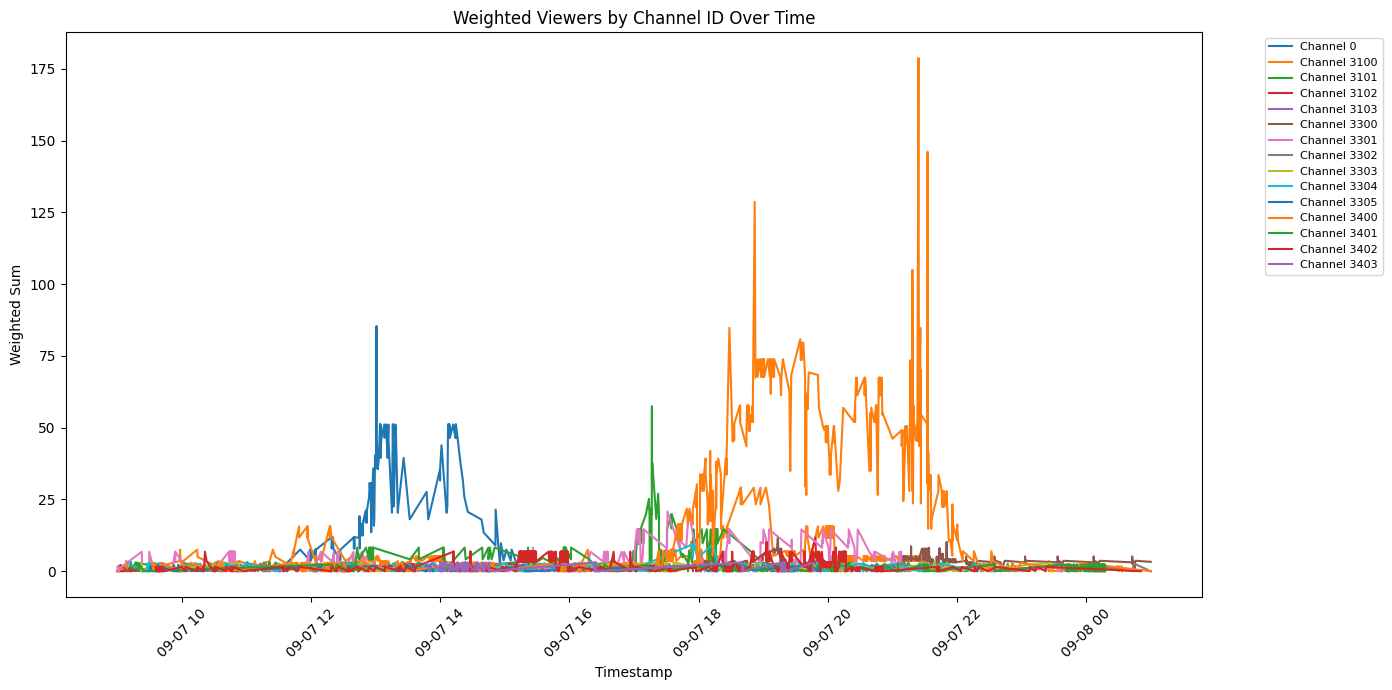

Total records: 4496, Channels: 15


In [16]:
plot_target_group(df[df["ts"] >pd.to_datetime("2025-09-07 09:00") ], tv_date="2025-09-07",group="f1229")